## Implicit classification

This notebook explores *implicit learning* approaches where the model discovers patterns from raw data rather than hand-crafted summary statistics.

### Philosophy

Instead of telling the model "look at hold ratio" or "look at timing variance", we let it:
1. *N-gram approach*: Learn from raw pattern frequencies and transitions
2. *Sequence model*: Learn directly from step sequences using an LSTM

This is more "natural" — the model figures out what matters rather than us injecting assumptions.

In [1]:
import json
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
)

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

PROJECT_ROOT = Path('..').resolve()
REAL_DIR = PROJECT_ROOT / 'data' / 'real'
ARTIFICIAL_DIR = PROJECT_ROOT / 'data' / 'artificial'

SEED = 42
np.random.seed(SEED)

### 1. Load data

In [2]:
def load_all_charts(base_dir: Path, label: int) -> list[dict]:
    """Load all charts from a directory, assigning a label (0=human, 1=ai)."""
    charts = []
    for dataset in ['fraxtil', 'itg']:
        dataset_dir = base_dir / dataset
        if not dataset_dir.exists():
            continue
        for json_path in dataset_dir.glob('*.json'):
            with open(json_path, 'r') as f:
                data = json.load(f)
            song_name = data.get('song_name', json_path.stem)
            for diff_name, chart_data in data.get('charts', {}).items():
                steps = chart_data.get('steps', [])
                if len(steps) < 10:
                    continue
                charts.append({
                    'song_name': song_name,
                    'dataset': dataset,
                    'difficulty': diff_name,
                    'steps': steps,
                    'label': label
                })
    return charts

human_charts = load_all_charts(REAL_DIR, label=0)
ai_charts = load_all_charts(ARTIFICIAL_DIR, label=1)
all_charts = human_charts + ai_charts

display(Markdown(f"Loaded {len(human_charts)} human and {len(ai_charts)} AI charts ({len(all_charts)} total)"))

Loaded 1094 human and 1101 AI charts (2195 total)

### 2. Train/test split

Split by song to prevent data leakage.

In [3]:
songs = list(set(c['song_name'] for c in all_charts))
np.random.shuffle(songs)

n_train = int(len(songs) * 0.8)
train_songs = set(songs[:n_train])
test_songs = set(songs[n_train:])

train_charts = [c for c in all_charts if c['song_name'] in train_songs]
test_charts = [c for c in all_charts if c['song_name'] in test_songs]

y_train = np.array([c['label'] for c in train_charts])
y_test = np.array([c['label'] for c in test_charts])

split_df = pd.DataFrame({
    'Split': ['Train', 'Test'],
    'Charts': [len(train_charts), len(test_charts)],
    'Songs': [len(train_songs), len(test_songs)],
    'Human': [sum(1 for c in train_charts if c['label'] == 0), sum(1 for c in test_charts if c['label'] == 0)],
    'AI': [sum(1 for c in train_charts if c['label'] == 1), sum(1 for c in test_charts if c['label'] == 1)]
})
display(split_df.set_index('Split'))

,Charts,Songs,Human,AI
Split,,,,
Train,1752,177,873,879
Test,443,45,221,222


### Approach 1: n-gram features

Instead of hand-crafted features, we extract:
- *Unigrams*: Frequency of each step pattern (e.g., how often `0001` appears)
- *Bigrams*: Frequency of transitions (e.g., how often `0001 → 0010` occurs)
- *Delta-time histogram*: Distribution of time gaps between steps


In [4]:
def extract_ngram_features(chart: dict, timing_bins: int = 20) -> dict:
    steps = chart['steps']
    patterns = [s['step'] for s in steps]
    times = [s['time'] for s in steps]
    
    features = {}
    
    unigram_counts = Counter(patterns)
    total = len(patterns)
    for pattern, count in unigram_counts.items():
        features[f'uni_{pattern}'] = count / total
    
    bigrams = list(zip(patterns[:-1], patterns[1:]))
    bigram_counts = Counter(bigrams)
    total_bigrams = len(bigrams) or 1
    for (p1, p2), count in bigram_counts.items():
        features[f'bi_{p1}_{p2}'] = count / total_bigrams
    
    if len(times) > 1:
        deltas = np.diff(times)
        deltas = deltas[deltas > 0]
        if len(deltas) > 0:
            hist, _ = np.histogram(deltas, bins=timing_bins, range=(0, 2), density=True)
            for i, val in enumerate(hist):
                features[f'dt_bin_{i}'] = val
    
    return features

train_features = [extract_ngram_features(c) for c in train_charts]
test_features = [extract_ngram_features(c) for c in test_charts]

vectorizer = DictVectorizer(sparse=False)
X_train_ngram = vectorizer.fit_transform(train_features)
X_test_ngram = vectorizer.transform(test_features)

display(Markdown(f"Extracted **{X_train_ngram.shape[1]}** n-gram features (unigrams + bigrams + timing bins)"))

Extracted **2000** n-gram features (unigrams + bigrams + timing bins)

### Train n-gram models

In [5]:
ngram_models = {
    'Logistic regression': LogisticRegression(random_state=SEED, max_iter=1000, C=0.1),
    'Random forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=SEED),
    'Gradient boosting': GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=SEED),
}

ngram_results = {}

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_ngram)
X_test_scaled = scaler.transform(X_test_ngram)

for name, model in ngram_models.items():
    X_tr = X_train_scaled if 'Logistic' in name else X_train_ngram
    X_te = X_test_scaled if 'Logistic' in name else X_test_ngram
    
    model.fit(X_tr, y_train)
    
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]
    
    ngram_results[name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_proba),
        'model': model,
        'y_pred': y_pred,
        'y_proba': y_proba,
    }

results_df = pd.DataFrame({
    name: {k: v for k, v in m.items() if k not in ['model', 'y_pred', 'y_proba']}
    for name, m in ngram_results.items()
}).T

display(Markdown("**N-gram model performance**"))
display(results_df.style.format('{:.3f}').background_gradient(cmap='Greens', axis=None))

**N-gram model performance**

,accuracy,precision,recall,f1,roc_auc
Logistic regression,0.716,0.694,0.775,0.732,0.784
Random forest,0.822,0.762,0.937,0.840,0.901
Gradient boosting,0.858,0.814,0.928,0.867,0.944


### What did the model learn?

Let's see which n-grams the model found most discriminative.

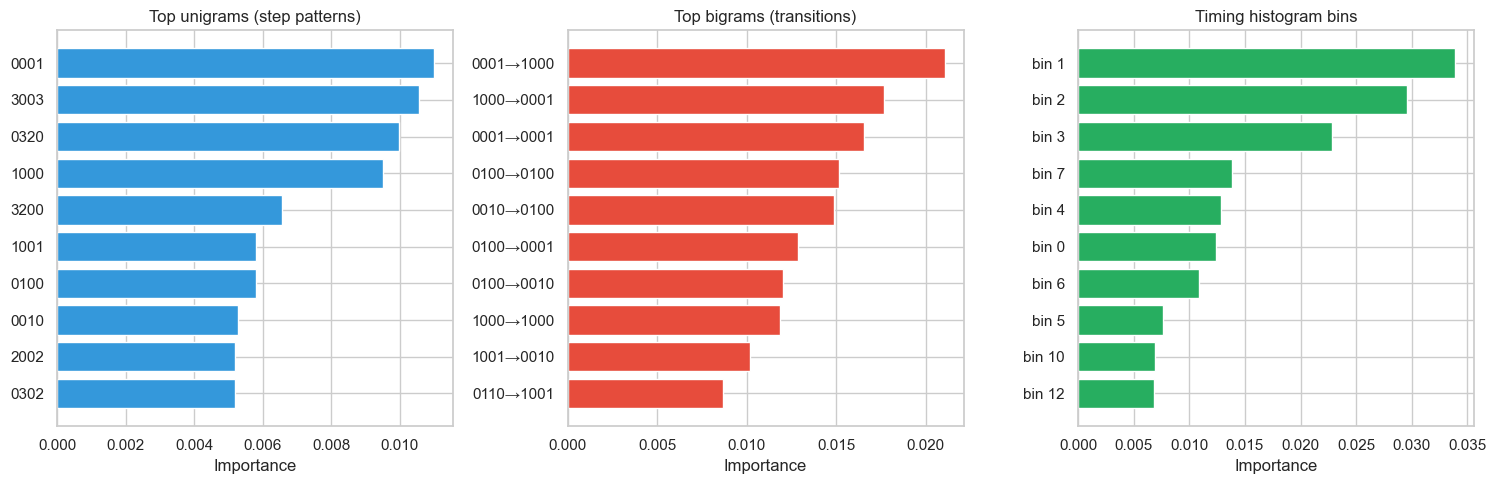

In [6]:
feature_names = vectorizer.get_feature_names_out()
rf_model = ngram_results['Random forest']['model']
importances = rf_model.feature_importances_

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

unigrams = importance_df[importance_df['feature'].str.startswith('uni_')].head(10)
bigrams = importance_df[importance_df['feature'].str.startswith('bi_')].head(10)
timing = importance_df[importance_df['feature'].str.startswith('dt_')].head(10)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].barh(unigrams['feature'].str.replace('uni_', ''), unigrams['importance'], color='#3498db')
axes[0].set_xlabel('Importance')
axes[0].set_title('Top unigrams (step patterns)')
axes[0].invert_yaxis()

axes[1].barh(bigrams['feature'].str.replace('bi_', '').str.replace('_', '→'), bigrams['importance'], color='#e74c3c')
axes[1].set_xlabel('Importance')
axes[1].set_title('Top bigrams (transitions)')
axes[1].invert_yaxis()

axes[2].barh(timing['feature'].str.replace('dt_bin_', 'bin '), timing['importance'], color='#27ae60')
axes[2].set_xlabel('Importance')
axes[2].set_title('Timing histogram bins')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

### Approach 2: sequence Model (LSTM)

The most "natural" approach: treat each chart as a sequence of steps and let an LSTM learn the patterns directly.

The model sees raw sequences like `['0001', '0100', '1000', '0010', ...]` and learns:
- Transition patterns that feel "human" vs "AI"
- Long-range dependencies in step placement
- Temporal structure without explicit feature engineering

In [7]:
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
    from tensorflow.keras.preprocessing.sequence import pad_sequences
    from tensorflow.keras.callbacks import EarlyStopping
    TF_AVAILABLE = True
    display(Markdown(f"TensorFlow **{tf.__version__}** available"))
except ImportError:
    TF_AVAILABLE = False
    display(Markdown("TensorFlow not installed. Run `uv add tensorflow` to enable LSTM model."))

TensorFlow **2.20.0** available

In [8]:
if TF_AVAILABLE:
    all_patterns = set()
    for chart in all_charts:
        all_patterns.update(s['step'] for s in chart['steps'])
    
    pattern_encoder = LabelEncoder()
    pattern_encoder.fit(list(all_patterns))
    vocab_size = len(all_patterns) + 1
    
    MAX_LEN = 300
    
    def chart_to_sequence(chart):
        patterns = [s['step'] for s in chart['steps']]
        encoded = pattern_encoder.transform(patterns) + 1
        return encoded
    
    X_train_seq = [chart_to_sequence(c) for c in train_charts]
    X_test_seq = [chart_to_sequence(c) for c in test_charts]
    
    X_train_seq = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
    X_test_seq = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')
    
    display(Markdown(f"Prepared sequences: vocab size = **{vocab_size}**, max length = **{MAX_LEN}**"))
else:
    display(Markdown("Skipping sequence preparation (TensorFlow not available)"))


Prepared sequences: vocab size = **147**, max length = **300**

### Build and train LSTM

In [9]:
if TF_AVAILABLE:
    model = Sequential([
        Embedding(vocab_size, 32, input_length=MAX_LEN, mask_zero=True),
        Bidirectional(LSTM(64, return_sequences=True)),
        Dropout(0.3),
        Bidirectional(LSTM(32)),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    model.summary()
else:
    display(Markdown("Skipping model build (TensorFlow not available)"))


/Users/enscribe/Repositories/School/cse158-a2/.venv/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
if TF_AVAILABLE:
    history = model.fit(
        X_train_seq, y_train,
        validation_split=0.15,
        epochs=30,
        batch_size=32,
        verbose=1
    )
else:
    display(Markdown("Skipping training (TensorFlow not available)"))


Epoch 1/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 17s 223ms/step - accuracy: 0.5836 - loss: 0.6782 - val_accuracy: 0.0000e+00 - val_loss: 0.8579
Epoch 2/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 219ms/step - accuracy: 0.6145 - loss: 0.6182 - val_accuracy: 0.7605 - val_loss: 0.7687
Epoch 3/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 224ms/step - accuracy: 0.6917 - loss: 0.5576 - val_accuracy: 0.8023 - val_loss: 0.6271
Epoch 4/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 11s 235ms/step - accuracy: 0.7179 - loss: 0.5292 - val_accuracy: 0.7985 - val_loss: 0.6138
Epoch 5/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 12s 246ms/step - accuracy: 0.7132 - loss: 0.5118 - val_accuracy: 0.7605 - val_loss: 0.6612
Epoch 6/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 223ms/step - accuracy: 0.7408 - loss: 0.4941 - val_accuracy: 0.3688 - val_loss: 1.0671
Epoch 7/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 11s 227ms/step - accuracy: 0.7260 - loss: 0.5041 - val_accuracy: 0.7529 - val_loss: 0.6261
Epoch 8/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 11s 243ms/step - accuracy: 0.7361 - loss: 0.4859 - val_

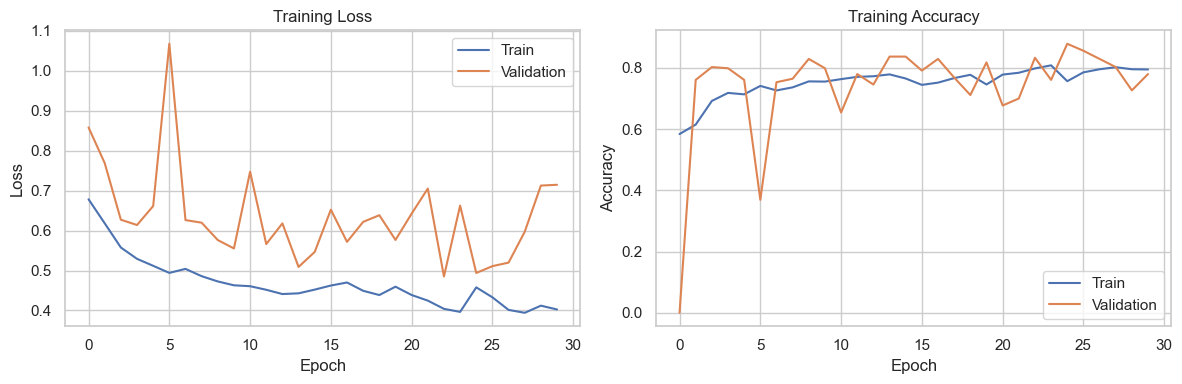

In [ ]:
if TF_AVAILABLE:
    # Training curves
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    axes[0].plot(history.history['loss'], label='Train')
    axes[0].plot(history.history['val_loss'], label='Validation')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training Loss')
    axes[0].legend()
    
    axes[1].plot(history.history['accuracy'], label='Train')
    axes[1].plot(history.history['val_accuracy'], label='Validation')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Training Accuracy')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

In [ ]:
if TF_AVAILABLE:
    y_proba_lstm = model.predict(X_test_seq).flatten()
    y_pred_lstm = (y_proba_lstm > 0.5).astype(int)
    
    lstm_results = {
        'accuracy': accuracy_score(y_test, y_pred_lstm),
        'precision': precision_score(y_test, y_pred_lstm),
        'recall': recall_score(y_test, y_pred_lstm),
        'f1': f1_score(y_test, y_pred_lstm),
        'roc_auc': roc_auc_score(y_test, y_proba_lstm),
    }
    
    display(Markdown("**LSTM sequence model performance**"))
    display(pd.DataFrame([lstm_results]).T.rename(columns={0: 'Value'}).style.format('{:.3f}'))

14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step


**LSTM sequence model performance**

,Value
accuracy,0.765
precision,0.784
recall,0.734
f1,0.758
roc_auc,0.861


### Comparison: all approaches

In [13]:
comparison = {}

best_ngram = max(ngram_results.keys(), key=lambda k: ngram_results[k]['roc_auc'])
comparison[f'N-gram ({best_ngram})'] = {
    'accuracy': ngram_results[best_ngram]['accuracy'],
    'roc_auc': ngram_results[best_ngram]['roc_auc'],
    'features': X_train_ngram.shape[1],
    'approach': 'Semi-implicit'
}

if TF_AVAILABLE:
    comparison['LSTM (sequence)'] = {
        'accuracy': lstm_results['accuracy'],
        'roc_auc': lstm_results['roc_auc'],
        'features': 'learned',
        'approach': 'Fully implicit'
    }

comparison_df = pd.DataFrame(comparison).T
display(Markdown("**Comparison of implicit learning approaches**"))
display(comparison_df)


**Comparison of implicit learning approaches**

,accuracy,roc_auc,features,approach
N-gram (Gradient boosting),0.857788,0.944071,2000,Semi-implicit
LSTM (sequence),0.765237,0.860809,learned,Fully implicit


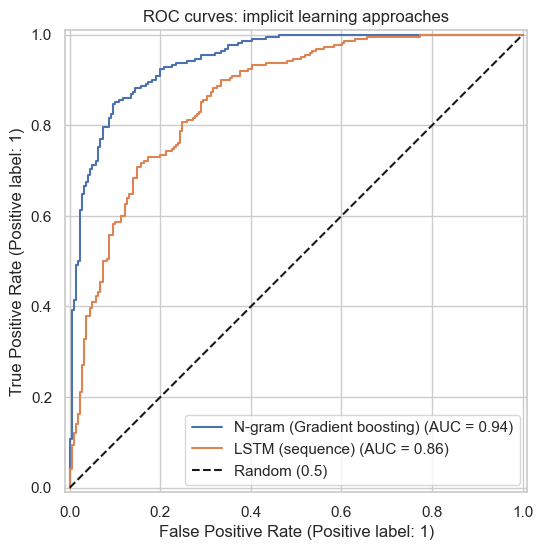

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))

best_ngram_result = ngram_results[best_ngram]
RocCurveDisplay.from_predictions(
    y_test, best_ngram_result['y_proba'], 
    name=f'N-gram ({best_ngram})', ax=ax
)

if TF_AVAILABLE:
    RocCurveDisplay.from_predictions(
        y_test, y_proba_lstm, 
        name='LSTM (sequence)', ax=ax
    )

ax.plot([0, 1], [0, 1], 'k--', label='Random (0.5)')
ax.set_title('ROC curves: implicit learning approaches')
ax.legend(loc='lower right')
plt.show()